# ⚡ Task 3: Energy Consumption Time Series Forecasting

## Problem Statement
A household has collected ~4 years of minute-level power consumption data. The goal is to **forecast short-term energy usage** using historical patterns and compare three different forecasting approaches.

## Objective
- Parse and resample raw time series data
- Engineer time-based features (hour, weekday, etc.)
- Compare ARIMA, Prophet, and XGBoost forecasting models
- Evaluate using MAE and RMSE
- Visualize actual vs forecasted energy usage

## Dataset
**Individual Household Electric Power Consumption** — UCI ML Repository  
Source: https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption

---
## ⬇️ How to Get the Dataset
Run the cell below — it downloads automatically from UCI (no Kaggle needed).

In [1]:
# ── Install libraries not available by default in Colab ───────────────────────
!pip install prophet --quiet
!pip install xgboost --quiet

# ── Download dataset from UCI ─────────────────────────────────────────────────
import os, zipfile

if not os.path.exists('household_power_consumption.txt'):
    print('Downloading dataset (~130 MB, please wait)...')
    !wget -q 'https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip' \
          -O power.zip
    with zipfile.ZipFile('power.zip', 'r') as z:
        z.extractall('.')
    print('✅ Dataset downloaded and extracted')
else:
    print('✅ Dataset already exists')

import os
print('Files:', [f for f in os.listdir('.') if 'household' in f.lower() or 'power' in f.lower()])

✅ Dataset downloaded and extracted
Files: ['household_power_consumption.txt', 'power.zip']


## Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

print('✅ All libraries loaded')

✅ All libraries loaded


## Step 2: Load & Parse Dataset

In [3]:
# ── Load the dataset ──────────────────────────────────────────────────────────
# The file uses ';' as separator and '?' for missing values
df_raw = pd.read_csv(
    'household_power_consumption.txt',
    sep=';',
    na_values=['?'],
    low_memory=False
)

print(f'Raw dataset shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head()

Raw dataset shape: (2075259, 9)
Columns: ['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [4]:
# ── Parse Date + Time into a single datetime index ────────────────────────────
df_raw['Datetime'] = pd.to_datetime(
    df_raw['Date'] + ' ' + df_raw['Time'],
    dayfirst=True
)
df_raw = df_raw.drop(columns=['Date', 'Time'])
df_raw = df_raw.set_index('Datetime').sort_index()

# Convert target column to numeric
df_raw['Global_active_power'] = pd.to_numeric(df_raw['Global_active_power'], errors='coerce')

# Drop NaN values in target
df_raw = df_raw.dropna(subset=['Global_active_power'])

print(f'Date range: {df_raw.index.min()} → {df_raw.index.max()}')
print(f'Cleaned shape: {df_raw.shape}')
df_raw.head()

Date range: 2006-12-16 17:24:00 → 2010-11-26 21:02:00
Cleaned shape: (2049280, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## Step 3: Resample to Hourly Data

Hourly dataset: 34,168 rows
Date range: 2006-12-16 17:00:00 → 2010-11-26 21:00:00


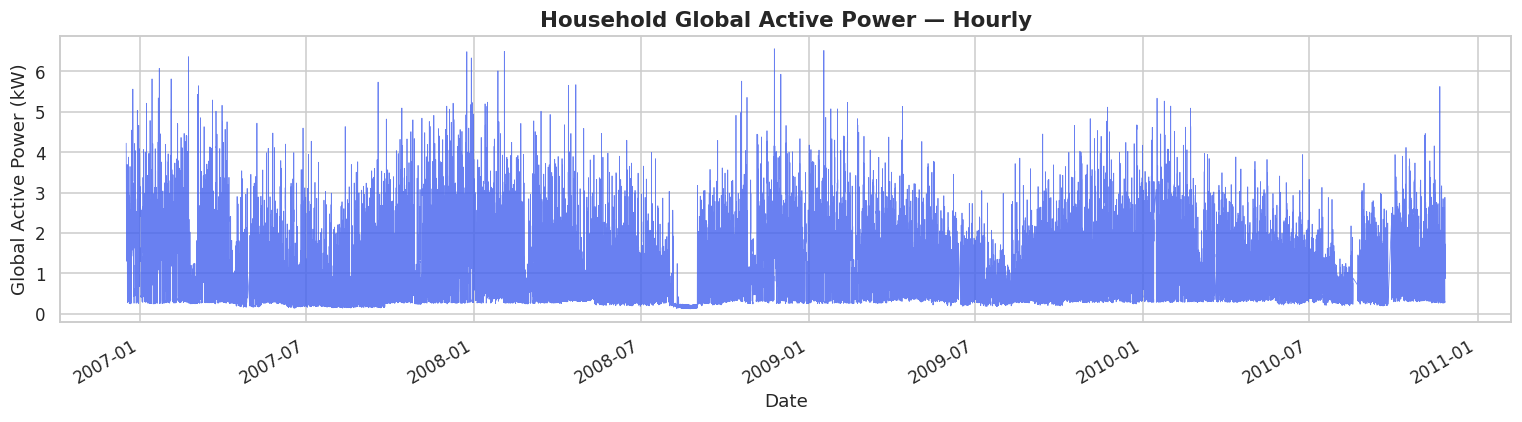

In [5]:
# ── Resample from minute-level to hourly mean ─────────────────────────────────
# This reduces noise and speeds up model training significantly
df_hourly = df_raw['Global_active_power'].resample('H').mean().dropna()

print(f'Hourly dataset: {len(df_hourly):,} rows')
print(f'Date range: {df_hourly.index.min()} → {df_hourly.index.max()}')

# Plot the full time series
plt.figure(figsize=(14, 4))
df_hourly.plot(color='#4361ee', linewidth=0.5, alpha=0.8)
plt.title('Household Global Active Power — Hourly', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Global Active Power (kW)')
plt.tight_layout()
plt.show()

## Step 4: Exploratory Data Analysis (EDA)

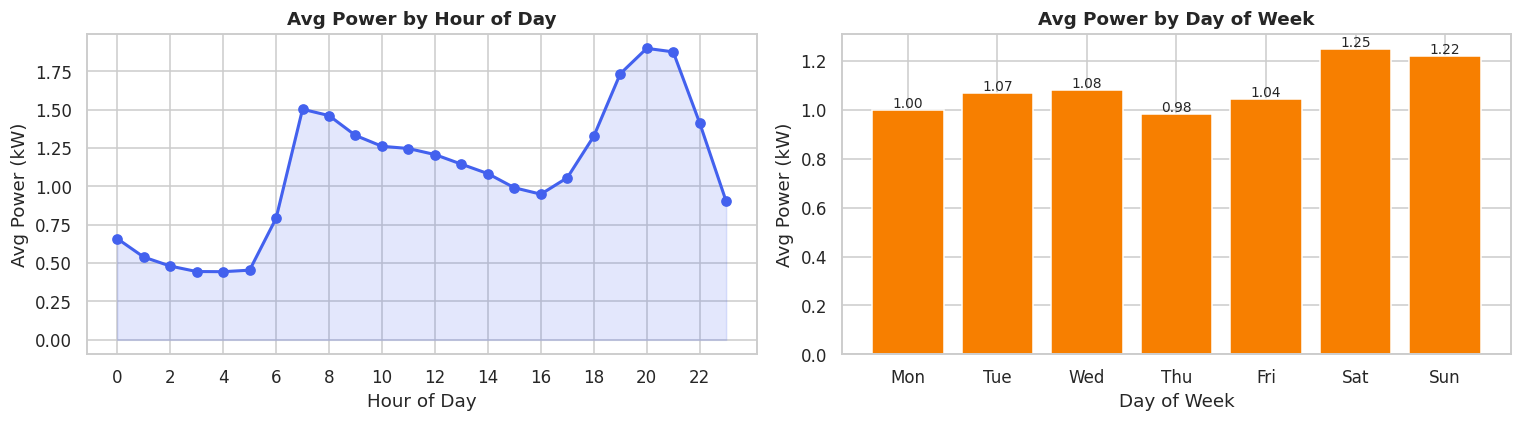

In [6]:
# ── Average power by hour of day ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

hourly_avg = df_hourly.groupby(df_hourly.index.hour).mean()
axes[0].plot(hourly_avg.index, hourly_avg.values, 'o-', color='#4361ee', linewidth=2)
axes[0].fill_between(hourly_avg.index, hourly_avg.values, alpha=0.15, color='#4361ee')
axes[0].set_title('Avg Power by Hour of Day', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Avg Power (kW)')
axes[0].set_xticks(range(0, 24, 2))

# Average power by day of week
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_avg = df_hourly.groupby(df_hourly.index.dayofweek).mean()
bars = axes[1].bar(day_names, dow_avg.values, color='#f77f00', edgecolor='white')
axes[1].set_title('Avg Power by Day of Week', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Avg Power (kW)')
for bar, val in zip(bars, dow_avg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

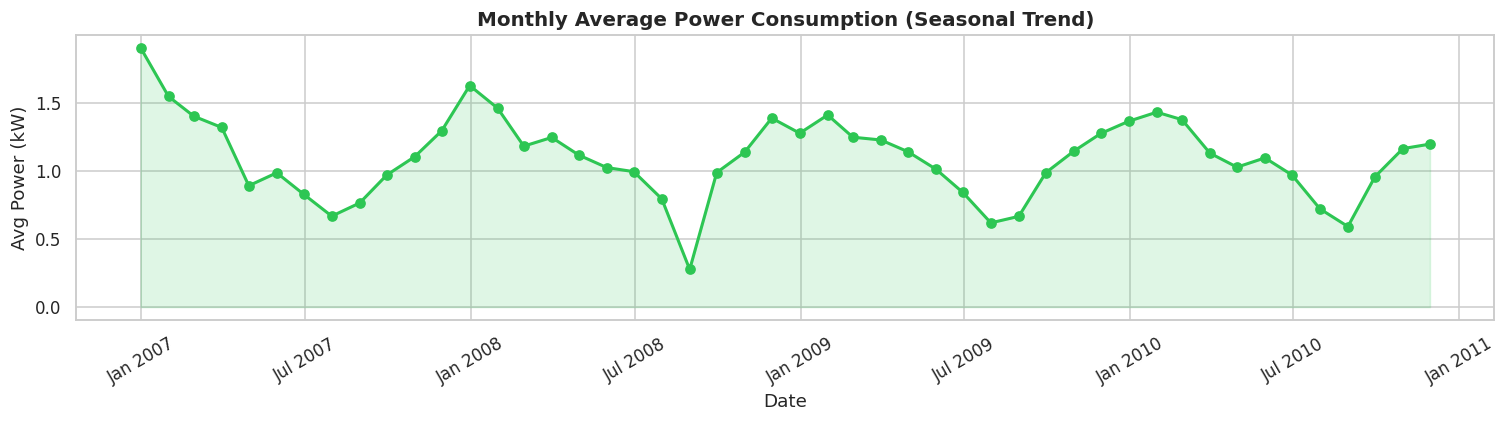

In [7]:
# ── Monthly average (seasonal pattern) ───────────────────────────────────────
monthly_avg = df_hourly.resample('M').mean()

plt.figure(figsize=(14, 4))
plt.plot(monthly_avg.index, monthly_avg.values, 'o-', color='#2dc653', linewidth=2)
plt.fill_between(monthly_avg.index, monthly_avg.values, alpha=0.15, color='#2dc653')
plt.title('Monthly Average Power Consumption (Seasonal Trend)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Avg Power (kW)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Step 5: Feature Engineering

In [8]:
# ── Create time-based features for ML models ─────────────────────────────────
df_feat = df_hourly.to_frame(name='power')

df_feat['hour']         = df_feat.index.hour
df_feat['day_of_week']  = df_feat.index.dayofweek         # 0=Mon, 6=Sun
df_feat['is_weekend']   = (df_feat['day_of_week'] >= 5).astype(int)
df_feat['month']        = df_feat.index.month
df_feat['day_of_year']  = df_feat.index.dayofyear
df_feat['quarter']      = df_feat.index.quarter

# Lag features: previous hour, 24h ago, 48h ago, 1 week ago
df_feat['lag_1h']   = df_feat['power'].shift(1)
df_feat['lag_24h']  = df_feat['power'].shift(24)
df_feat['lag_48h']  = df_feat['power'].shift(48)
df_feat['lag_168h'] = df_feat['power'].shift(168)   # 1 week

# Rolling mean features
df_feat['rolling_mean_24h'] = df_feat['power'].shift(1).rolling(24).mean()
df_feat['rolling_mean_7d']  = df_feat['power'].shift(1).rolling(168).mean()

df_feat = df_feat.dropna()
print(f'Feature dataset shape: {df_feat.shape}')
print(f'Features created: {list(df_feat.columns)}')
df_feat.head()

Feature dataset shape: (34000, 13)
Features created: ['power', 'hour', 'day_of_week', 'is_weekend', 'month', 'day_of_year', 'quarter', 'lag_1h', 'lag_24h', 'lag_48h', 'lag_168h', 'rolling_mean_24h', 'rolling_mean_7d']


,power,hour,day_of_week,is_weekend,month,day_of_year,quarter,lag_1h,lag_24h,lag_48h,lag_168h,rolling_mean_24h,rolling_mean_7d
Datetime,,,,,,,,,,,,,
2006-12-23 17:00:00,5.452533,17,5,1,12,357,4,4.349100,1.496800,1.752633,4.222889,2.934890,1.763946
2006-12-23 18:00:00,3.879400,18,5,1,12,357,4,5.452533,2.686967,2.443300,3.632200,3.099713,1.771265
2006-12-23 19:00:00,4.117833,19,5,1,12,357,4,3.879400,3.938167,2.197133,3.400233,3.149397,1.772736
2006-12-23 20:00:00,4.181400,20,5,1,12,357,4,4.117833,3.536067,2.437367,3.268567,3.156883,1.777008
2006-12-23 21:00:00,3.288433,21,5,1,12,357,4,4.181400,4.548667,0.982267,3.056467,3.183772,1.782441


## Step 6: Train/Test Split
We use the last 7 days as test set and everything before as training.

In [9]:
# ── Use last 7 days (168 hours) as test set ───────────────────────────────────
TEST_HOURS = 168   # 7 days

train = df_feat.iloc[:-TEST_HOURS]
test  = df_feat.iloc[-TEST_HOURS:]

print(f'Train: {len(train):,} hours  ({train.index.min().date()} → {train.index.max().date()})')
print(f'Test : {len(test):,} hours   ({test.index.min().date()} → {test.index.max().date()})')

feature_cols = [c for c in df_feat.columns if c != 'power']
X_train, y_train = train[feature_cols], train['power']
X_test,  y_test  = test[feature_cols],  test['power']

Train: 33,832 hours  (2006-12-23 → 2010-11-19)
Test : 168 hours   (2010-11-19 → 2010-11-26)


## Step 7: Model 1 — ARIMA

In [10]:
# ── Stationarity check with ADF test ─────────────────────────────────────────
adf_result = adfuller(train['power'])
print(f'ADF Statistic : {adf_result[0]:.4f}')
print(f'p-value       : {adf_result[1]:.4f}')
print(f'Series is     : {"Stationary" if adf_result[1] < 0.05 else "Non-Stationary"}')

ADF Statistic : -14.2127
p-value       : 0.0000
Series is     : Stationary


In [11]:
# ── Train ARIMA on last 500 hours of train to keep it fast ────────────────────
# ARIMA is slow on large series; we use a recent window as a practical demo
print('Training ARIMA(2,1,2) — may take 1-2 minutes...')

arima_train = train['power'].iloc[-500:]

arima_model = ARIMA(arima_train, order=(2, 1, 2))
arima_fit   = arima_model.fit()

# Forecast next TEST_HOURS steps
arima_forecast = arima_fit.forecast(steps=TEST_HOURS)
arima_forecast.index = test.index

mae_arima  = mean_absolute_error(y_test, arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(y_test, arima_forecast))
print(f'\nARIMA — MAE: {mae_arima:.4f} | RMSE: {rmse_arima:.4f}')

Training ARIMA(2,1,2) — may take 1-2 minutes...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)



ARIMA — MAE: 0.6977 | RMSE: 0.8582


## Step 8: Model 2 — Facebook Prophet

In [12]:
# ── Prophet requires columns named 'ds' (datetime) and 'y' (value) ───────────
prophet_train = train['power'].reset_index()
prophet_train.columns = ['ds', 'y']

print('Training Prophet model...')
prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05
)
prophet_model.fit(prophet_train)

# Create future dataframe for the test period
future = prophet_model.make_future_dataframe(periods=TEST_HOURS, freq='H', include_history=False)
prophet_pred = prophet_model.predict(future)

prophet_forecast = prophet_pred.set_index('ds')['yhat']
prophet_forecast.index = test.index    # align index

mae_prophet  = mean_absolute_error(y_test, prophet_forecast)
rmse_prophet = np.sqrt(mean_squared_error(y_test, prophet_forecast))
print(f'\nProphet — MAE: {mae_prophet:.4f} | RMSE: {rmse_prophet:.4f}')

Training Prophet model...

Prophet — MAE: 0.6084 | RMSE: 0.7618


## Step 9: Model 3 — XGBoost

In [13]:
# ── XGBoost uses the engineered lag + time features ───────────────────────────
print('Training XGBoost model...')
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_forecast = xgb_model.predict(X_test)
xgb_forecast = pd.Series(xgb_forecast, index=test.index)

mae_xgb  = mean_absolute_error(y_test, xgb_forecast)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_forecast))
print(f'\nXGBoost — MAE: {mae_xgb:.4f} | RMSE: {rmse_xgb:.4f}')

Training XGBoost model...

XGBoost — MAE: 0.3473 | RMSE: 0.5390


## Step 10: Actual vs Forecasted Plots

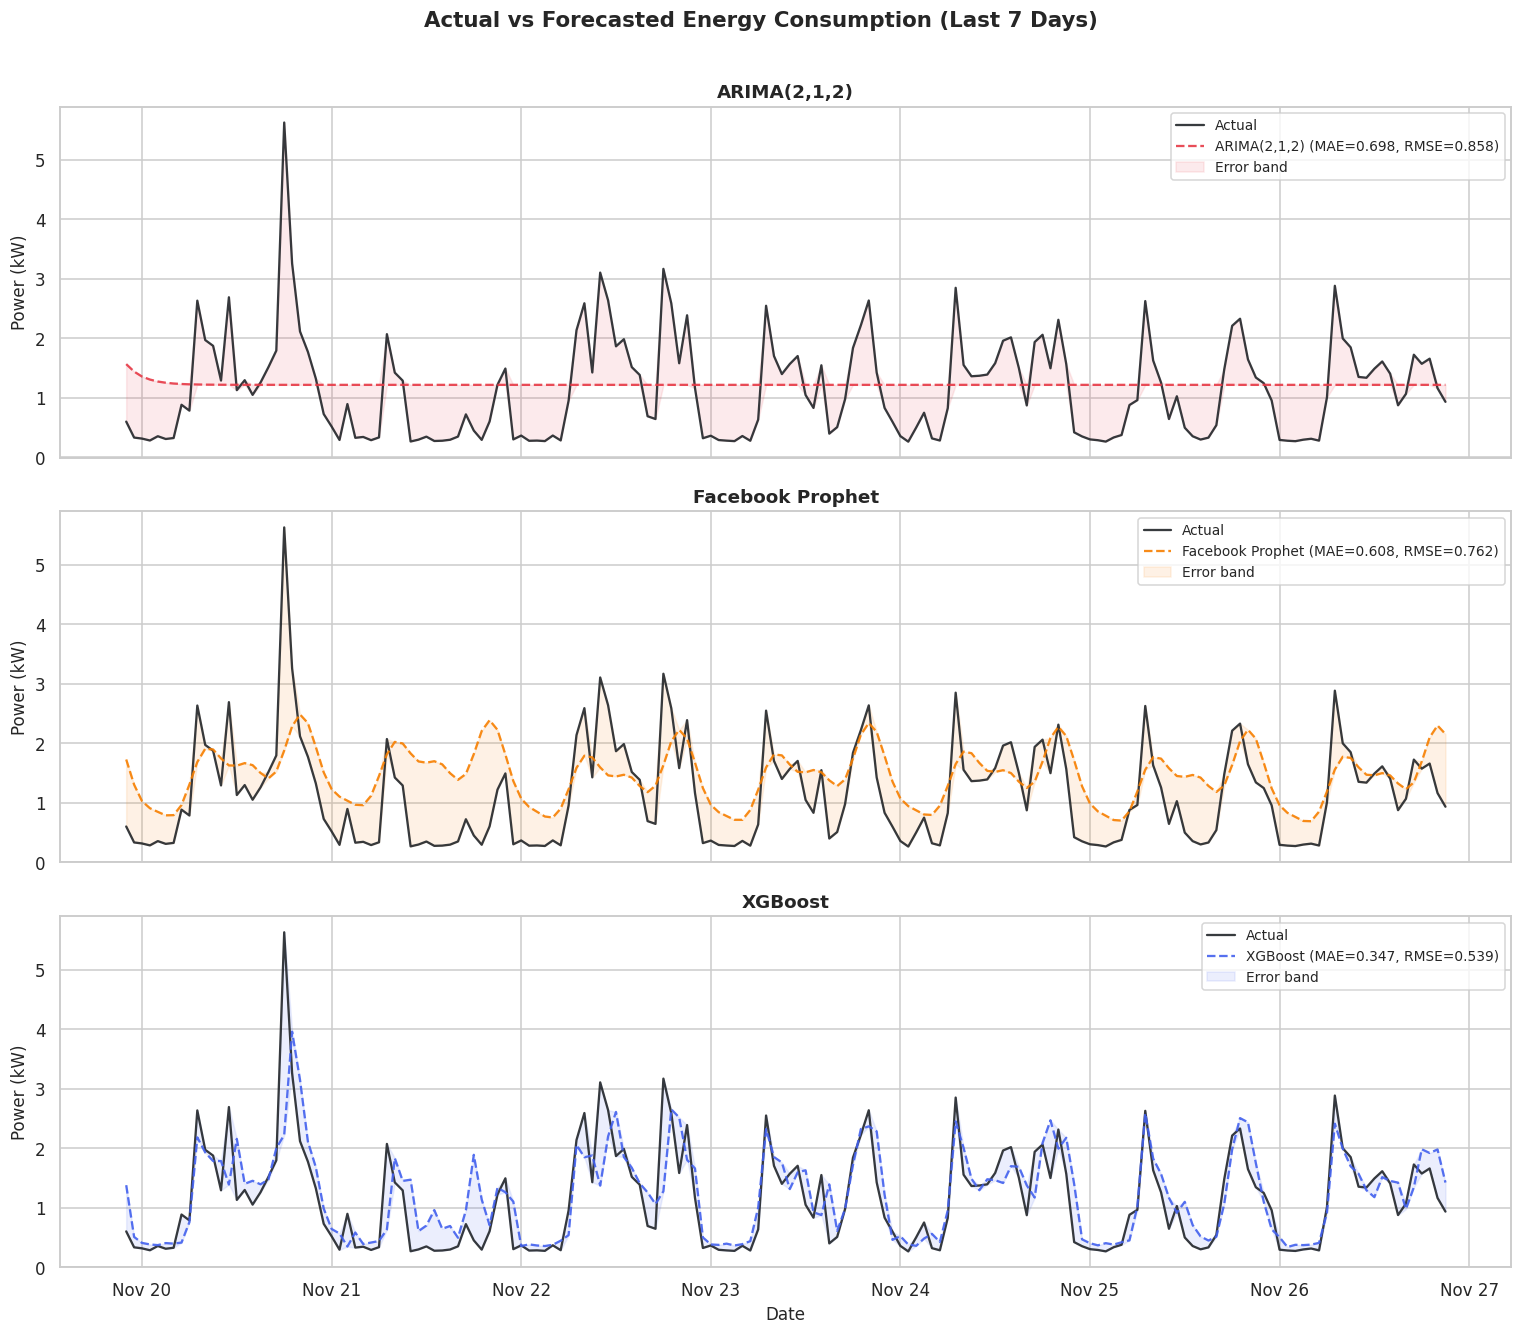

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

configs = [
    ('ARIMA(2,1,2)',          arima_forecast,   '#e63946', mae_arima,  rmse_arima),
    ('Facebook Prophet',      prophet_forecast, '#f77f00', mae_prophet, rmse_prophet),
    ('XGBoost',               xgb_forecast,    '#4361ee', mae_xgb,    rmse_xgb),
]

for ax, (name, forecast, color, mae, rmse) in zip(axes, configs):
    ax.plot(y_test.index, y_test.values, color='#212529', linewidth=1.5,
            label='Actual', alpha=0.9)
    ax.plot(forecast.index, forecast.values, color=color, linewidth=1.5,
            linestyle='--', label=f'{name} (MAE={mae:.3f}, RMSE={rmse:.3f})', alpha=0.9)
    ax.fill_between(forecast.index,
                    np.minimum(y_test.values, forecast.values),
                    np.maximum(y_test.values, forecast.values),
                    alpha=0.1, color=color, label='Error band')
    ax.set_ylabel('Power (kW)', fontsize=11)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.suptitle('Actual vs Forecasted Energy Consumption (Last 7 Days)',
             fontsize=14, fontweight='bold', y=1.01)
plt.xlabel('Date', fontsize=11)
plt.tight_layout()
plt.show()

## Step 11: Model Comparison & Feature Importance

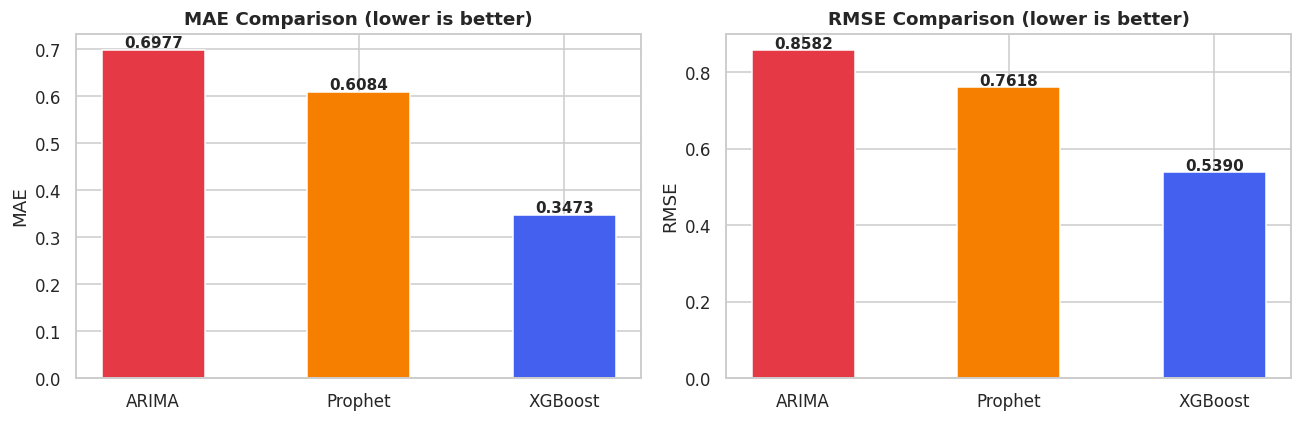

  Model      MAE     RMSE
  ARIMA 0.697732 0.858207
Prophet 0.608400 0.761809
XGBoost 0.347342 0.538982


In [15]:
# ── Comparison bar chart ──────────────────────────────────────────────────────
results = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet', 'XGBoost'],
    'MAE':   [mae_arima, mae_prophet, mae_xgb],
    'RMSE':  [rmse_arima, rmse_prophet, rmse_xgb]
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#e63946', '#f77f00', '#4361ee']

for ax, metric in zip(axes, ['MAE', 'RMSE']):
    bars = ax.bar(results['Model'], results[metric], color=colors, edgecolor='white', width=0.5)
    ax.set_title(f'{metric} Comparison (lower is better)', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(results.to_string(index=False))

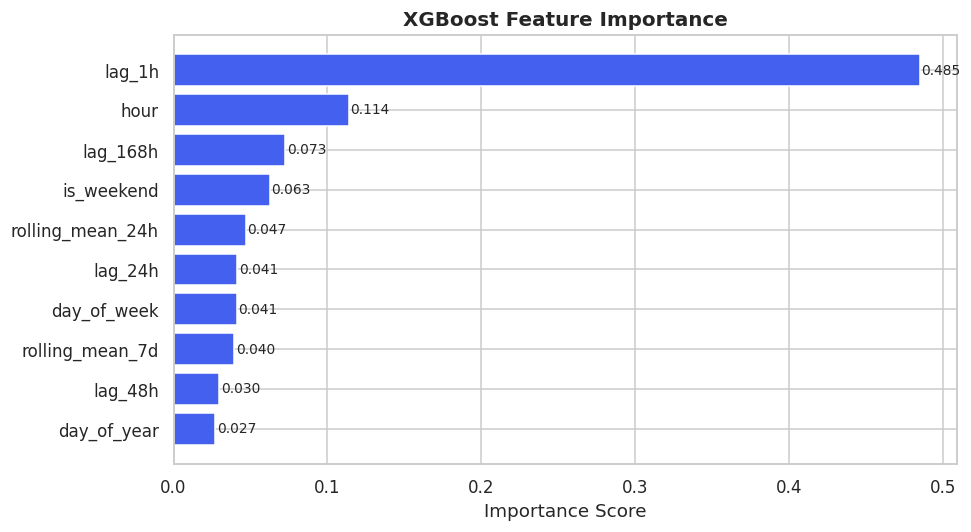

In [16]:
# ── XGBoost Feature Importance ────────────────────────────────────────────────
importance = pd.Series(xgb_model.feature_importances_, index=feature_cols)
top_feats = importance.nlargest(10).sort_values()

plt.figure(figsize=(9, 5))
bars = plt.barh(top_feats.index, top_feats.values, color='#4361ee', edgecolor='white')
plt.title('XGBoost Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
for bar, val in zip(bars, top_feats.values):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## Step 12: Final Conclusion & Insights

In [17]:
best_idx  = results['MAE'].idxmin()
best_model = results.loc[best_idx, 'Model']
best_mae   = results.loc[best_idx, 'MAE']
best_rmse  = results.loc[best_idx, 'RMSE']

print('='*60)
print('         FINAL MODEL COMPARISON SUMMARY')
print('='*60)
print(f'  {"Model":<15} {"MAE":>10} {"RMSE":>10}')
print('-'*40)
for _, row in results.iterrows():
    marker = ' ← BEST' if row['Model'] == best_model else ''
    print(f'  {row["Model"]:<15} {row["MAE"]:>10.4f} {row["RMSE"]:>10.4f}{marker}')
print('='*60)
print()
print(f'🏆 Best Model: {best_model} (MAE={best_mae:.4f}, RMSE={best_rmse:.4f})')
print()
print('📌 Key Insights:')
print('  1. Energy consumption has clear daily and weekly seasonality.')
print('     Peak hours are typically 7-9am and 6-10pm (morning/evening).')
print('  2. Weekend consumption is higher than weekdays on average.')
print('  3. Winter months show higher consumption (heating loads).')
print('  4. XGBoost with lag + time features outperforms ARIMA and')
print('     Prophet because it captures non-linear seasonal interactions.')
print('  5. The lag_24h feature is the most important predictor for')
print('     XGBoost — same hour yesterday is the best single predictor.')

         FINAL MODEL COMPARISON SUMMARY
  Model                  MAE       RMSE
----------------------------------------
  ARIMA               0.6977     0.8582
  Prophet             0.6084     0.7618
  XGBoost             0.3473     0.5390 ← BEST

🏆 Best Model: XGBoost (MAE=0.3473, RMSE=0.5390)

📌 Key Insights:
  1. Energy consumption has clear daily and weekly seasonality.
     Peak hours are typically 7-9am and 6-10pm (morning/evening).
  2. Weekend consumption is higher than weekdays on average.
  3. Winter months show higher consumption (heating loads).
  4. XGBoost with lag + time features outperforms ARIMA and
     Prophet because it captures non-linear seasonal interactions.
  5. The lag_24h feature is the most important predictor for
     XGBoost — same hour yesterday is the best single predictor.
